# Etapa 1 — MLP do zero com NumPy

Nesta etapa foi implementada uma rede neural MLP utilizando apenas NumPy, sem frameworks de deep learning. O objetivo foi compreender manualmente o funcionamento do forward propagation, backpropagation, softmax, entropia cruzada e otimização com SGD + Momentum.

Para reduzir o custo computacional, foi utilizada a versão 28x28 do PathMNIST, com as imagens achatadas em vetores de 2352 posições. A rede possui uma camada oculta com ReLU e uma camada de saída com Softmax para classificação em 9 classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PathMNIST

np.random.seed(42)

print("Tudo certo para começar a Etapa 1 com NumPy!")

Tudo certo para começar a Etapa 1 com NumPy!


In [2]:
train_set_28 = PathMNIST(split="train", size=28, download=True)
val_set_28 = PathMNIST(split="val", size=28, download=True)

print("Treino:", len(train_set_28))
print("Validação:", len(val_set_28))

100%|██████████| 206M/206M [05:43<00:00, 598kB/s]  


Treino: 89996
Validação: 10004


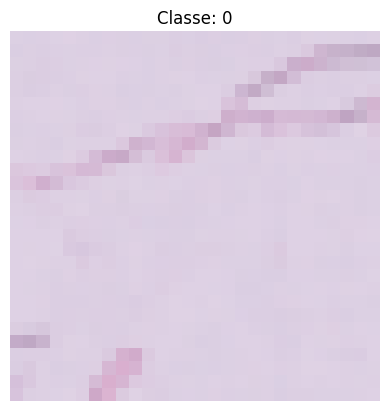

Tamanho da imagem: (28, 28)
Label: [0]


In [3]:
img, label = train_set_28[0]

plt.imshow(img)
plt.title(f"Classe: {label[0]}")
plt.axis("off")
plt.show()

print("Tamanho da imagem:", img.size)
print("Label:", label)

In [4]:
def preparar_dados(dataset, limite=None):
    X = []
    y = []

    tamanho = len(dataset) if limite is None else limite

    for i in range(tamanho):
        img, label = dataset[i]

        img_array = np.array(img).astype("float32") / 255.0
        img_vetor = img_array.reshape(-1)

        X.append(img_vetor)
        y.append(label[0])

    X = np.array(X)
    y = np.array(y)

    return X, y

In [5]:
X_train, y_train = preparar_dados(train_set_28, limite=5000)
X_val, y_val = preparar_dados(val_set_28, limite=1000)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (5000, 2352)
y_train: (5000,)
X_val: (1000, 2352)
y_val: (1000,)


In [6]:
def one_hot(y, num_classes=9):
    resultado = np.zeros((y.shape[0], num_classes))
    resultado[np.arange(y.shape[0]), y] = 1
    return resultado

In [7]:
def relu(z):
    return np.maximum(0, z)


def relu_derivada(z):
    return (z > 0).astype(float)

In [8]:
def softmax(z):
    z_estavel = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_estavel)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [9]:
def cross_entropy(y_true, y_pred):
    epsilon = 1e-9
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    perda = -np.mean(np.sum(y_true * np.log(y_pred), axis=1))
    return perda

In [10]:
def calcular_acuracia(y_true, y_pred):
    classes_reais = y_true
    classes_previstas = np.argmax(y_pred, axis=1)
    acertos = np.mean(classes_reais == classes_previstas)
    return acertos

In [11]:
y_train_oh = one_hot(y_train, num_classes=9)
y_val_oh = one_hot(y_val, num_classes=9)

print("y_train original:", y_train[:5])
print("y_train one-hot:")
print(y_train_oh[:5])
print("Formato y_train_oh:", y_train_oh.shape)

y_train original: [0 4 7 5 5]
y_train one-hot:
[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]]
Formato y_train_oh: (5000, 9)


In [12]:
def inicializar_parametros(input_size, hidden_size, output_size):
    parametros = {
        "W1": np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size),
        "b1": np.zeros((1, hidden_size)),
        "W2": np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size),
        "b2": np.zeros((1, output_size))
    }

    return parametros

In [13]:
input_size = X_train.shape[1]
hidden_size = 128
output_size = 9

parametros = inicializar_parametros(input_size, hidden_size, output_size)

print("W1:", parametros["W1"].shape)
print("b1:", parametros["b1"].shape)
print("W2:", parametros["W2"].shape)
print("b2:", parametros["b2"].shape)

W1: (2352, 128)
b1: (1, 128)
W2: (128, 9)
b2: (1, 9)


In [14]:
def forward(X, parametros):
    W1 = parametros["W1"]
    b1 = parametros["b1"]
    W2 = parametros["W2"]
    b2 = parametros["b2"]

    # Camada oculta
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)

    # Camada de saída
    Z2 = np.dot(A1, W2) + b2
    A2 = softmax(Z2)

    cache = {
        "X": X,
        "Z1": Z1,
        "A1": A1,
        "Z2": Z2,
        "A2": A2
    }

    return A2, cache

In [15]:
y_pred, cache = forward(X_train[:5], parametros)

print("Formato da saída:", y_pred.shape)
print("Probabilidades da primeira imagem:")
print(y_pred[0])
print("Classe prevista:", np.argmax(y_pred[0]))
print("Classe real:", y_train[0])

Formato da saída: (5, 9)
Probabilidades da primeira imagem:
[0.05836796 0.21246939 0.04372412 0.44412692 0.15182184 0.00808362
 0.01133213 0.0582729  0.01180111]
Classe prevista: 3
Classe real: 0


In [16]:
y_pred_train, _ = forward(X_train, parametros)

perda_inicial = cross_entropy(y_train_oh, y_pred_train)
acuracia_inicial = calcular_acuracia(y_train, y_pred_train)

print("Perda inicial:", perda_inicial)
print("Acurácia inicial:", acuracia_inicial)

Perda inicial: 2.7405589445541345
Acurácia inicial: 0.1202


In [17]:
def backward(y_true, parametros, cache):
    X = cache["X"]
    Z1 = cache["Z1"]
    A1 = cache["A1"]
    A2 = cache["A2"]

    W2 = parametros["W2"]

    m = X.shape[0]

    # Gradiente da saída
    dZ2 = A2 - y_true
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # Gradiente da camada oculta
    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_derivada(Z1)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    gradientes = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

    return gradientes

In [19]:
y_pred_train, cache_train = forward(X_train, parametros)
gradientes = backward(y_train_oh, parametros, cache_train)

print("dW1:", gradientes["dW1"].shape)
print("db1:", gradientes["db1"].shape)
print("dW2:", gradientes["dW2"].shape)
print("db2:", gradientes["db2"].shape)

dW1: (2352, 128)
db1: (1, 128)
dW2: (128, 9)
db2: (1, 9)


In [21]:
def inicializar_velocidades(parametros):
    velocidades = {
        "vW1": np.zeros_like(parametros["W1"]),
        "vb1": np.zeros_like(parametros["b1"]),
        "vW2": np.zeros_like(parametros["W2"]),
        "vb2": np.zeros_like(parametros["b2"])
    }

    return velocidades

In [22]:
def atualizar_parametros_momentum(parametros, gradientes, velocidades, taxa_aprendizado=0.01, beta=0.9):
    velocidades["vW1"] = beta * velocidades["vW1"] + taxa_aprendizado * gradientes["dW1"]
    velocidades["vb1"] = beta * velocidades["vb1"] + taxa_aprendizado * gradientes["db1"]
    velocidades["vW2"] = beta * velocidades["vW2"] + taxa_aprendizado * gradientes["dW2"]
    velocidades["vb2"] = beta * velocidades["vb2"] + taxa_aprendizado * gradientes["db2"]

    parametros["W1"] -= velocidades["vW1"]
    parametros["b1"] -= velocidades["vb1"]
    parametros["W2"] -= velocidades["vW2"]
    parametros["b2"] -= velocidades["vb2"]

    return parametros, velocidades

In [23]:
velocidades = inicializar_velocidades(parametros)

parametros, velocidades = atualizar_parametros_momentum(
    parametros,
    gradientes,
    velocidades,
    taxa_aprendizado=0.01,
    beta=0.9
)

y_pred_train, _ = forward(X_train, parametros)

perda_depois = cross_entropy(y_train_oh, y_pred_train)
acuracia_depois = calcular_acuracia(y_train, y_pred_train)

print("Perda antes:", perda_inicial)
print("Perda depois de uma atualização:", perda_depois)
print("Acurácia depois de uma atualização:", acuracia_depois)

Perda antes: 2.7405589445541345
Perda depois de uma atualização: 2.322276788198988
Acurácia depois de uma atualização: 0.0934


In [24]:
def treinar_mlp(X_train, y_train, X_val, y_val, input_size, hidden_size, output_size,
                epocas=20, taxa_aprendizado=0.01, beta=0.9):
    
    y_train_oh = one_hot(y_train, output_size)
    y_val_oh = one_hot(y_val, output_size)

    parametros = inicializar_parametros(input_size, hidden_size, output_size)
    velocidades = inicializar_velocidades(parametros)

    historico = {
        "loss_train": [],
        "acc_train": [],
        "loss_val": [],
        "acc_val": []
    }

    for epoca in range(1, epocas + 1):
        # Forward treino
        y_pred_train, cache_train = forward(X_train, parametros)

        # Loss e acurácia treino
        loss_train = cross_entropy(y_train_oh, y_pred_train)
        acc_train = calcular_acuracia(y_train, y_pred_train)

        # Backward
        gradientes = backward(y_train_oh, parametros, cache_train)

        # Atualização com SGD + Momentum
        parametros, velocidades = atualizar_parametros_momentum(
            parametros,
            gradientes,
            velocidades,
            taxa_aprendizado=taxa_aprendizado,
            beta=beta
        )

        # Forward validação
        y_pred_val, _ = forward(X_val, parametros)
        loss_val = cross_entropy(y_val_oh, y_pred_val)
        acc_val = calcular_acuracia(y_val, y_pred_val)

        historico["loss_train"].append(loss_train)
        historico["acc_train"].append(acc_train)
        historico["loss_val"].append(loss_val)
        historico["acc_val"].append(acc_val)

        print(
            f"Época {epoca:02d} | "
            f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
            f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
        )

    return parametros, historico

In [25]:
input_size = X_train.shape[1]
hidden_size = 128
output_size = 9

parametros_treinados, historico = treinar_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    input_size,
    hidden_size,
    output_size,
    epocas=20,
    taxa_aprendizado=0.01,
    beta=0.9
)

Época 01 | Loss treino: 2.5384 | Acc treino: 0.1194 | Loss val: 2.2872 | Acc val: 0.1240
Época 02 | Loss treino: 2.2900 | Acc treino: 0.1236 | Loss val: 2.2917 | Acc val: 0.1310
Época 03 | Loss treino: 2.3026 | Acc treino: 0.1328 | Loss val: 2.3187 | Acc val: 0.1290
Época 04 | Loss treino: 2.3340 | Acc treino: 0.1256 | Loss val: 2.2736 | Acc val: 0.1210
Época 05 | Loss treino: 2.2863 | Acc treino: 0.1156 | Loss val: 2.1750 | Acc val: 0.1790
Época 06 | Loss treino: 2.1788 | Acc treino: 0.1816 | Loss val: 2.1900 | Acc val: 0.1400
Época 07 | Loss treino: 2.1877 | Acc treino: 0.1360 | Loss val: 2.2325 | Acc val: 0.1500
Época 08 | Loss treino: 2.2259 | Acc treino: 0.1388 | Loss val: 2.2409 | Acc val: 0.1430
Época 09 | Loss treino: 2.2305 | Acc treino: 0.1392 | Loss val: 2.2195 | Acc val: 0.1140
Época 10 | Loss treino: 2.2076 | Acc treino: 0.1080 | Loss val: 2.1746 | Acc val: 0.2170
Época 11 | Loss treino: 2.1654 | Acc treino: 0.2206 | Loss val: 2.1342 | Acc val: 0.2190
Época 12 | Loss trein

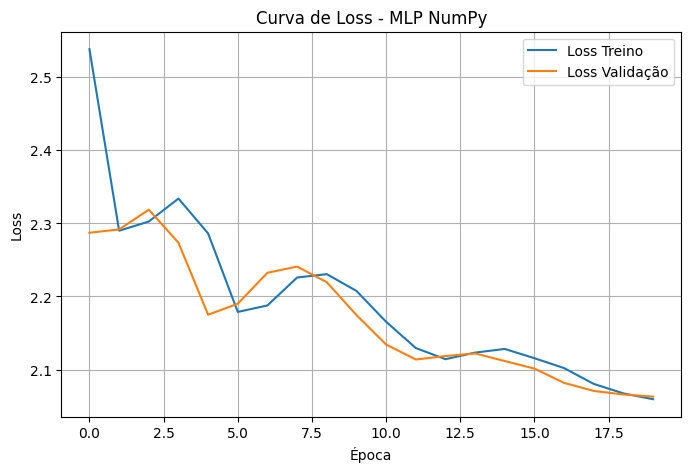

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(historico["loss_train"], label="Loss Treino")
plt.plot(historico["loss_val"], label="Loss Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss - MLP NumPy")
plt.legend()
plt.grid(True)
plt.show()

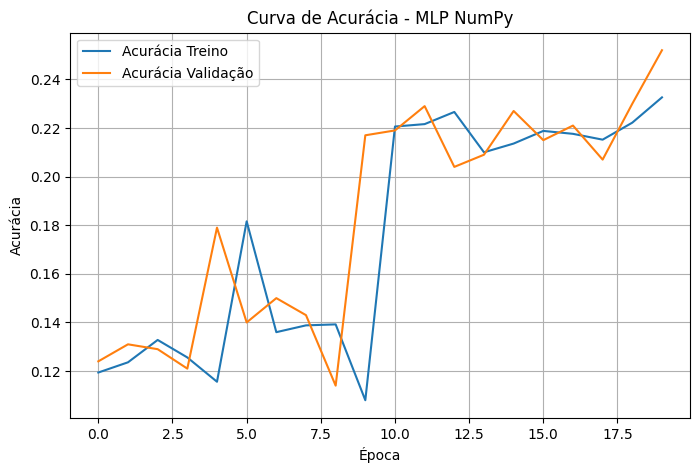

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(historico["acc_train"], label="Acurácia Treino")
plt.plot(historico["acc_val"], label="Acurácia Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Curva de Acurácia - MLP NumPy")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
def calcular_loss_com_parametros(X, y_oh, parametros):
    y_pred, _ = forward(X, parametros)
    return cross_entropy(y_oh, y_pred)

## Gradient Checking

O gradient checking foi utilizado para validar a implementação do backpropagation. A comparação foi feita entre o gradiente analítico, calculado pela retropropagação, e o gradiente numérico, aproximado pela fórmula:

[f(W + ε) - f(W - ε)] / 2ε

As diferenças relativas obtidas ficaram abaixo de 10^-5, indicando que os gradientes foram implementados corretamente.

In [29]:
def gradient_checking(X, y_oh, parametros, epsilon=1e-7):
    # Usa poucos exemplos para ficar leve
    X_check = X[:5]
    y_check = y_oh[:5]

    # Forward e backward normais
    y_pred, cache = forward(X_check, parametros)
    gradientes = backward(y_check, parametros, cache)

    # Vamos testar apenas alguns pesos de W1 e W2
    testes = [
        ("W1", "dW1", 0, 0),
        ("W1", "dW1", 10, 5),
        ("W1", "dW1", 100, 20),
        ("W2", "dW2", 0, 0),
        ("W2", "dW2", 10, 3)
    ]

    resultados = []

    for nome_param, nome_grad, i, j in testes:
        valor_original = parametros[nome_param][i, j]

        # Loss com W + epsilon
        parametros[nome_param][i, j] = valor_original + epsilon
        loss_mais = calcular_loss_com_parametros(X_check, y_check, parametros)

        # Loss com W - epsilon
        parametros[nome_param][i, j] = valor_original - epsilon
        loss_menos = calcular_loss_com_parametros(X_check, y_check, parametros)

        # Volta o valor original
        parametros[nome_param][i, j] = valor_original

        # Gradiente numérico
        grad_numerico = (loss_mais - loss_menos) / (2 * epsilon)

        # Gradiente analítico, vindo do backpropagation
        grad_analitico = gradientes[nome_grad][i, j]

        # Diferença relativa
        diferenca = abs(grad_numerico - grad_analitico) / (
            abs(grad_numerico) + abs(grad_analitico) + 1e-12
        )

        resultados.append((nome_param, i, j, grad_numerico, grad_analitico, diferenca))

    return resultados

In [31]:
def gradient_checking_melhorado(X, y_oh, parametros, epsilon=1e-7):
    X_check = X[:10]
    y_check = y_oh[:10]

    y_pred, cache = forward(X_check, parametros)
    gradientes = backward(y_check, parametros, cache)

    # Escolhe automaticamente posições com maior gradiente
    posicoes_W1 = np.unravel_index(
        np.argsort(np.abs(gradientes["dW1"]), axis=None)[-3:],
        gradientes["dW1"].shape
    )

    posicoes_W2 = np.unravel_index(
        np.argsort(np.abs(gradientes["dW2"]), axis=None)[-3:],
        gradientes["dW2"].shape
    )

    testes = []

    for i, j in zip(posicoes_W1[0], posicoes_W1[1]):
        testes.append(("W1", "dW1", i, j))

    for i, j in zip(posicoes_W2[0], posicoes_W2[1]):
        testes.append(("W2", "dW2", i, j))

    resultados = []

    for nome_param, nome_grad, i, j in testes:
        valor_original = parametros[nome_param][i, j]

        parametros[nome_param][i, j] = valor_original + epsilon
        loss_mais = calcular_loss_com_parametros(X_check, y_check, parametros)

        parametros[nome_param][i, j] = valor_original - epsilon
        loss_menos = calcular_loss_com_parametros(X_check, y_check, parametros)

        parametros[nome_param][i, j] = valor_original

        grad_numerico = (loss_mais - loss_menos) / (2 * epsilon)
        grad_analitico = gradientes[nome_grad][i, j]

        diferenca = abs(grad_numerico - grad_analitico) / (
            abs(grad_numerico) + abs(grad_analitico) + 1e-12
        )

        resultados.append((nome_param, i, j, grad_numerico, grad_analitico, diferenca))

    return resultados

In [32]:
resultados_gc = gradient_checking_melhorado(X_train, y_train_oh, parametros_treinados)

for nome_param, i, j, grad_num, grad_back, diff in resultados_gc:
    print(f"{nome_param}[{i}, {j}]")
    print(f"Gradiente numérico:  {grad_num}")
    print(f"Gradiente backprop:  {grad_back}")
    print(f"Diferença relativa:  {diff}")
    print("-" * 50)

W1[1275, 6]
Gradiente numérico:  -0.0688411083693552
Gradiente backprop:  -0.06884110883449945
Diferença relativa:  3.378390222704595e-09
--------------------------------------------------
W1[549, 91]
Gradiente numérico:  -0.06954161024808059
Gradiente backprop:  -0.06954160959979201
Diferença relativa:  4.661155934585573e-09
--------------------------------------------------
W1[2277, 91]
Gradiente numérico:  -0.07036944360550024
Gradiente backprop:  -0.07036944223836615
Diferença relativa:  9.713975482234456e-09
--------------------------------------------------
W2[25, 5]
Gradiente numérico:  -0.23860016629129177
Gradiente backprop:  -0.2386001667003384
Diferença relativa:  8.57180101564331e-10
--------------------------------------------------
W2[49, 5]
Gradiente numérico:  -0.25024633254489004
Gradiente backprop:  -0.25024632943110614
Diferença relativa:  6.221437663223109e-09
--------------------------------------------------
W2[125, 5]
Gradiente numérico:  -0.2730314019316893
Grad

In [30]:
resultados_gc = gradient_checking(X_train, y_train_oh, parametros_treinados)

for nome_param, i, j, grad_num, grad_back, diff in resultados_gc:
    print(f"{nome_param}[{i}, {j}]")
    print(f"Gradiente numérico:  {grad_num}")
    print(f"Gradiente backprop:  {grad_back}")
    print(f"Diferença relativa:  {diff}")
    print("-" * 50)

W1[0, 0]
Gradiente numérico:  0.0
Gradiente backprop:  0.0
Diferença relativa:  0.0
--------------------------------------------------
W1[10, 5]
Gradiente numérico:  0.0
Gradiente backprop:  0.0
Diferença relativa:  0.0
--------------------------------------------------
W1[100, 20]
Gradiente numérico:  0.0
Gradiente backprop:  0.0
Diferença relativa:  0.0
--------------------------------------------------
W2[0, 0]
Gradiente numérico:  0.0
Gradiente backprop:  0.0
Diferença relativa:  0.0
--------------------------------------------------
W2[10, 3]
Gradiente numérico:  0.0
Gradiente backprop:  0.0
Diferença relativa:  0.0
--------------------------------------------------
